# Final

In [1]:
import os
import numpy as np
import random
from shutil import copyfile, rmtree
from tqdm import tqdm
import time

import tensorflow as tf
from tensorflow.keras import Model, layers, callbacks
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2

# =================== REPRODUCIBILITY ===================
SEED = 40
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# =================== CONSTANTS ===================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 60
train_ratio, val_ratio = 0.7, 0.15

# =================== DIRECTORIES ===================
dataset_dir = '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9'
base_dir = '/kaggle/working/colon_split'

# =================== CLEAN EXISTING SPLITS ===================
if os.path.exists(base_dir):
    for folder in os.listdir(base_dir):
        rmtree(os.path.join(base_dir, folder))

# =================== DATA SPLIT ===================
splits = ['train', 'val', 'test']
class_names = os.listdir(dataset_dir)

for split in splits:
    for class_name in class_names:
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

for class_name in class_names:
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    random.shuffle(image_list)

    n_total = len(image_list)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)

    train_files = image_list[:n_train]
    val_files = image_list[n_train:n_train + n_val]
    test_files = image_list[n_train + n_val:]

    for split, split_files in zip(['train', 'val', 'test'],
                                  [train_files, val_files, test_files]):
        for img in tqdm(split_files, desc=f'{class_name} - {split}'):
            src = os.path.join(dataset_dir, class_name, img)
            dst = os.path.join(base_dir, split, class_name, img)
            copyfile(src, dst)

# =================== DATA GENERATORS (NO RESCALING) ===================

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.xception.preprocess_input
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.xception.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ==================== MODEL ====================
def build_convnext_model():

    base_model = ConvNeXtTiny(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    base_model.trainable = True  
    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model


model = build_convnext_model()

# =================== OPTIMIZER & LOSS ===================
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1.5e-4,
    decay_steps=1000,
    alpha=1e-6
)

optimizer = AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-5
)

loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

# =================== CALLBACKS ===================
checkpoint_cb = callbacks.ModelCheckpoint(
    'convnexttiny.keras', monitor='val_accuracy', save_best_only=True, verbose=1
)

earlystop_cb = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=7, restore_best_weights=True
)

# ==================== TRAIN ====================
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

end_time = time.time()
total_train_time = end_time - start_time
epoch_count = len(history.history['loss'])
avg_epoch_time = total_train_time / epoch_count

print(f"\n🕒 Total training time: {total_train_time:.2f} seconds")
print(f"⏱️ Average time per epoch: {avg_epoch_time:.2f} seconds")

# ==================== EVALUATION ====================
model.load_weights("convnexttiny.keras")

test_loss, test_acc = model.evaluate(test_generator)

print(f"\n✅ Test Accuracy: {test_acc:.4f}")

2026-02-10 15:21:54.059847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770736914.257035      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770736914.321684      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
1_ulcerative_colitis - test: 100%|██████████| 225/225 [00:01<00:00, 113.06it/s]


Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.


I0000 00:00:1770736974.212475      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770736974.215552      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

 91/132 ━━━━━━━━━━━━━━━━━━━━ 28s 700ms/step - accuracy: 0.5971 - loss: 1.1449

E0000 00:00:1770737124.353970     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1770737124.488074     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1770737125.856196     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1770737125.988688     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 906ms/step - accuracy: 0.6572 - loss: 1.0250

E0000 00:00:1770737182.761041     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1770737182.895500     120 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.93000, saving model to convnexttiny.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.6584 - loss: 1.0227 - val_accuracy: 0.9300 - val_loss: 0.4925
Epoch 2/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - accuracy: 0.9665 - loss: 0.4456
Epoch 2: val_accuracy improved from 0.93000 to 0.97111, saving model to convnexttiny.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 108s 824ms/step - accuracy: 0.9666 - loss: 0.4455 - val_accuracy: 0.9711 - val_loss: 0.4107
Epoch 3/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.9900 - loss: 0.3900
Epoch 3: val_accuracy improved from 0.97111 to 0.97556, saving model to convnexttiny.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 108s 821ms/step - accuracy: 0.9900 - loss: 0.3900 - val_accuracy: 0.9756 - val_loss: 0.4009
Epoch 4/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - accuracy: 0.9980 - loss: 0.3682
Epoch 4: val_accuracy improved from 0.97556 to 0.97667, saving model to convnexttiny.keras
132/132 ━━━━━━

29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 275ms/step

================ CONFUSION MATRIX (RAW COUNTS) ================

[[224   1   0   0]
 [  0 222   2   1]
 [  0   9 216   0]
 [  0   0   0 225]]


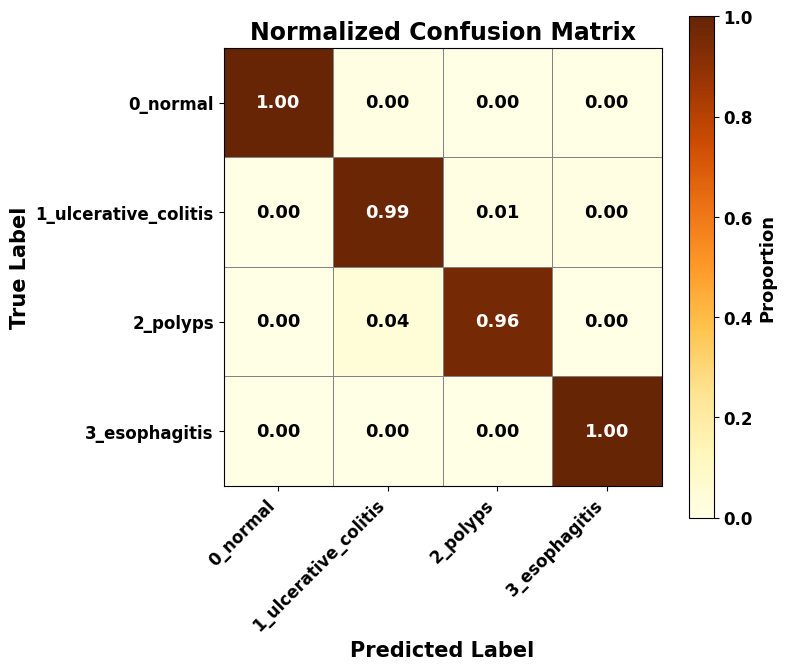


================ PER-CLASS METRICS ================

Class        Precision    Recall  F1-score   Support
------------------------------------------------------------
0_normal         1.000     0.996     0.998       225
1_ulcerative_colitis     0.957     0.987     0.972       225
2_polyps         0.991     0.960     0.975       225
3_esophagitis     0.996     1.000     0.998       225

================ MACRO-AVERAGED METRICS ================

Accuracy           : 0.9856
Precision (Macro)  : 0.9858
Recall (Macro)     : 0.9856
F1-score (Macro)   : 0.9856

================ CLASSIFICATION REPORT ================

                      precision    recall  f1-score   support

            0_normal      1.000     0.996     0.998       225
1_ulcerative_colitis      0.957     0.987     0.972       225
            2_polyps      0.991     0.960     0.975       225
       3_esophagitis      0.996     1.000     0.998       225

            accuracy                          0.986       900
        

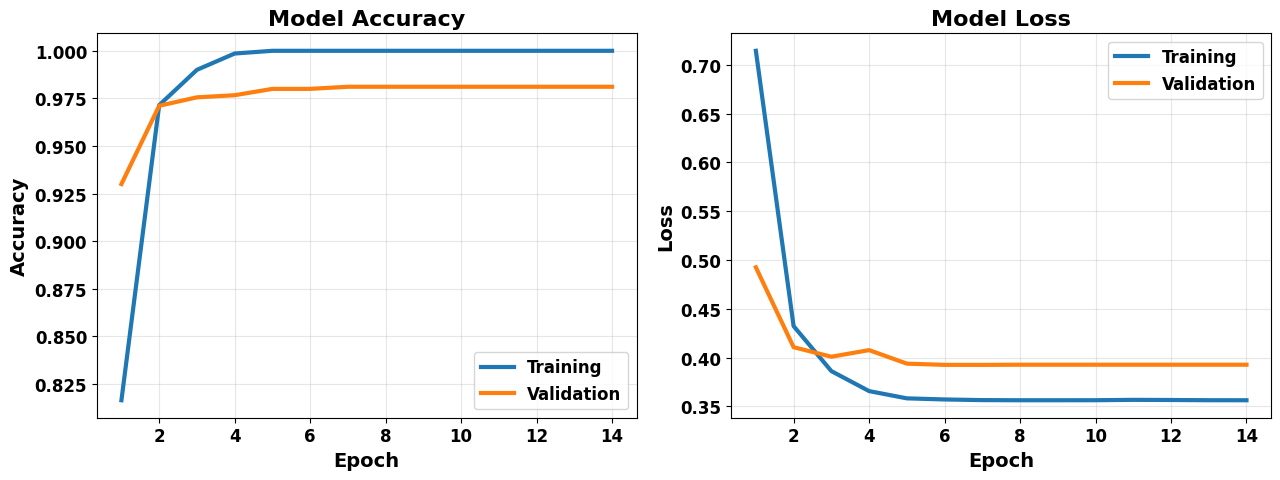

In [2]:
# =================== IMPORTS ===================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score
)

# =================== GLOBAL FONT SETTINGS ===================
plt.rcParams.update({
    'font.size': 13,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

# =================== PREDICTIONS ===================
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

class_labels = list(test_generator.class_indices.keys())
num_classes = len(class_labels)

# =================== CONFUSION MATRIX (RAW) ===================
cm = confusion_matrix(y_true, y_pred)

print("\n================ CONFUSION MATRIX (RAW COUNTS) ================\n")
print(cm)

# =================== CONFUSION MATRIX (NORMALIZED) ===================
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 7))
im = plt.imshow(cm_norm, cmap='YlOrBr', vmin=0, vmax=1)

cbar = plt.colorbar(im)
cbar.set_label("Proportion", fontweight='bold', fontsize=13)

plt.xticks(range(num_classes), class_labels, rotation=45, ha='right', fontweight='bold')
plt.yticks(range(num_classes), class_labels, fontweight='bold')

plt.xlabel("Predicted Label", fontsize=15, fontweight='bold')
plt.ylabel("True Label", fontsize=15, fontweight='bold')
plt.title("Normalized Confusion Matrix", fontsize=17, fontweight='bold')

plt.grid(False)

for i in range(num_classes + 1):
    plt.axhline(i - 0.5, color='gray', linewidth=0.7)
    plt.axvline(i - 0.5, color='gray', linewidth=0.7)

for i in range(num_classes):
    for j in range(num_classes):
        text_color = 'black' if cm_norm[i, j] < 0.7 else 'white'
        plt.text(
            j, i, f"{cm_norm[i, j]:.2f}",
            ha="center", va="center",
            fontsize=13,
            fontweight='bold',
            color=text_color
        )

plt.tight_layout()
plt.show()

# =================== PER-CLASS METRICS ===================
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None
)

print("\n================ PER-CLASS METRICS ================\n")
print(f"{'Class':12s} {'Precision':>9s} {'Recall':>9s} {'F1-score':>9s} {'Support':>9s}")
print("-" * 60)

for i, cls in enumerate(class_labels):
    print(f"{cls:12s} {precision[i]:9.3f} {recall[i]:9.3f} {f1[i]:9.3f} {support[i]:9d}")

# =================== MACRO-AVERAGED METRICS ===================
precision_macro = precision.mean()
recall_macro = recall.mean()
f1_macro = f1.mean()
accuracy = accuracy_score(y_true, y_pred)

print("\n================ MACRO-AVERAGED METRICS ================\n")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision_macro:.4f}")
print(f"Recall (Macro)     : {recall_macro:.4f}")
print(f"F1-score (Macro)   : {f1_macro:.4f}")

# =================== CLASSIFICATION REPORT ===================
print("\n================ CLASSIFICATION REPORT ================\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_labels,
    digits=3
))

# =================== TRAINING CURVES ===================
def plot_history(history):
    epochs = range(1, len(history.history['accuracy']) + 1)

    plt.figure(figsize=(13, 5))

    # Accuracy Curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], label='Training', linewidth=3)
    plt.plot(epochs, history.history['val_accuracy'], label='Validation', linewidth=3)
    plt.title('Model Accuracy', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Loss Curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], label='Training', linewidth=3)
    plt.plot(epochs, history.history['val_loss'], label='Validation', linewidth=3)
    plt.title('Model Loss', fontsize=16, fontweight='bold')

    # FIXED TYPO HERE
    plt.xlabel('Epoch', fontsize=14, fontweight='bold')
    plt.ylabel('Loss', fontsize=14, fontweight='bold')

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Call the function
plot_history(history)
